In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("../data/hotel_bookings_cleaned.csv")

print("Dataset shape:", df.shape)

# Target variable
y = df["adr"]

# Remove target and columns that are outcomes/post-booking information
X = df.drop(columns=[
    "adr",
    "reservation_status",
    "reservation_status_date",
    "is_canceled"
])

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Preprocessing for tree-based models
preprocessor = ColumnTransformer(
    transformers=[
        ("cat",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_cols),

        ("num",
         "passthrough",
         numerical_cols)
    ]
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Target: ADR")

Dataset shape: (87394, 37)
Training data: (69915, 33)
Testing data: (17479, 33)
Target: ADR


C:\Users\manin\AppData\Local\Temp\ipykernel_26840\1913393266.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


Best max_depth: {'model__max_depth': 15}

Decision Tree Results
----------------------
MAE : 14.08
RMSE: 24.15
R²  : 0.7893

Top 15 Important Features:
                               Feature  Importance
248                  num__total_guests    0.204559
231      num__arrival_date_week_number    0.144790
0                cat__hotel_City Hotel    0.090048
3       cat__arrival_date_month_August    0.076945
201          cat__reserved_room_type_A    0.057920
230             num__arrival_date_year    0.044936
229                     num__lead_time    0.041611
242                         num__agent    0.037823
195      cat__market_segment_Online TA    0.032407
247                  num__total_nights    0.030666
7         cat__arrival_date_month_July    0.023434
190  cat__market_segment_Complementary    0.023280
192         cat__market_segment_Direct    0.022851
1              cat__hotel_Resort Hotel    0.019326
194  cat__market_segment_Offline TA/TO    0.018986


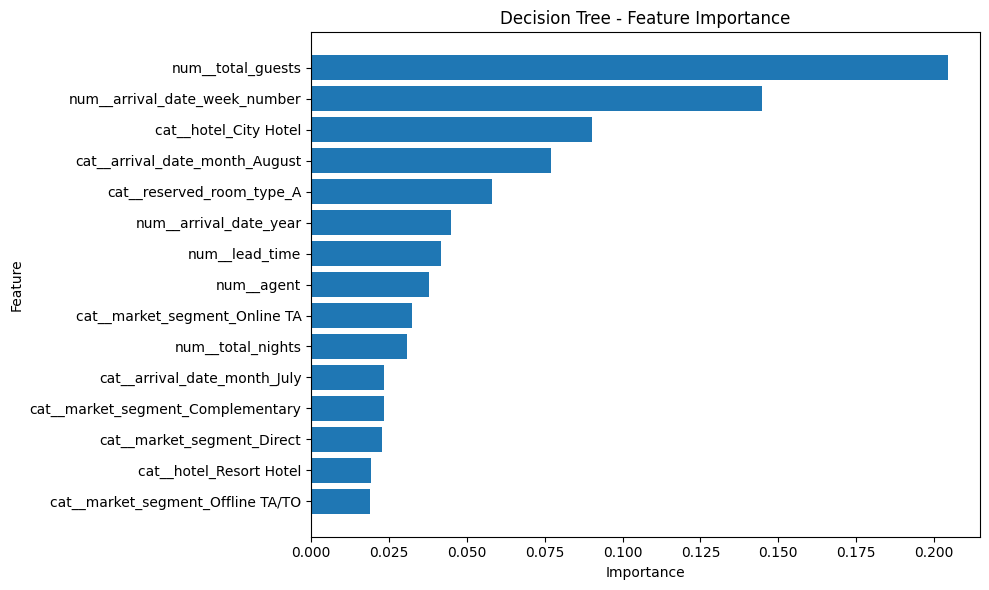

In [2]:
from sklearn.tree import DecisionTreeRegressor

# Create pipeline
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

# Tune max_depth
dt_params = {
    "model__max_depth": [3, 5, 10, 15, 20]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    dt_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Train
dt_grid.fit(X_train, y_train)

# Best parameter
print("Best max_depth:", dt_grid.best_params_)

# Prediction
dt_pred = dt_grid.predict(X_test)

# Evaluation
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("\nDecision Tree Results")
print("----------------------")
print("MAE :", round(dt_mae, 2))
print("RMSE:", round(dt_rmse, 2))
print("R²  :", round(dt_r2, 4))

# Feature importance
dt_model = dt_grid.best_estimator_.named_steps["model"]

feature_names = dt_grid.best_estimator_.named_steps[
    "preprocessor"
].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Important Features:")
print(importance_df.head(15))
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree - Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Baseline Random Forest
rf_pipeline.fit(X_train, y_train)

rf_baseline_pred = rf_pipeline.predict(X_test)

print("Random Forest Baseline")
print("----------------------")
print("MAE :",
      round(mean_absolute_error(y_test, rf_baseline_pred), 2))

print("RMSE:",
      round(np.sqrt(mean_squared_error(y_test, rf_baseline_pred)), 2))

print("R²  :",
      round(r2_score(y_test, rf_baseline_pred), 4))


# Tune n_estimators
rf_params = {
    "model__n_estimators": [50, 100, 200]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("\nBest Parameters:")
print(rf_grid.best_params_)

# Prediction
rf_pred = rf_grid.predict(X_test)

# Evaluation
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("\nTuned Random Forest Results")
print("---------------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting pipeline
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    ))
])

# Tune learning rate
gb_params = {
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2]
}

gb_grid = GridSearchCV(
    gb_pipeline,
    gb_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Train
gb_grid.fit(X_train, y_train)

print("Best Parameters:")
print(gb_grid.best_params_)

# Prediction
gb_pred = gb_grid.predict(X_test)

# Evaluation
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("\nGradient Boosting Results")
print("-------------------------")
print("MAE :", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²  :", round(gb_r2, 4))

In [ ]:
from sklearn.svm import SVR

# Take sample for SVR because SVR is computationally expensive
X_train_svr = X_train.sample(
    n=15000,
    random_state=42
)

y_train_svr = y_train.loc[X_train_svr.index]

# Preprocessing with StandardScaler
svr_preprocessor = ColumnTransformer([
    ("cat",
     OneHotEncoder(handle_unknown="ignore"),
     categorical_cols),

    ("num",
     StandardScaler(),
     numerical_cols)
])

# SVR pipeline
svr_pipeline = Pipeline([
    ("preprocessor", svr_preprocessor),
    ("model", SVR())
])

# Tune C and kernel
svr_params = {
    "model__C": [1, 10, 100],
    "model__kernel": ["linear", "rbf"]
}

svr_grid = GridSearchCV(
    svr_pipeline,
    svr_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Train
svr_grid.fit(X_train_svr, y_train_svr)

print("Best Parameters:")
print(svr_grid.best_params_)

# Prediction
svr_pred = svr_grid.predict(X_test)

# Evaluation
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_r2 = r2_score(y_test, svr_pred)

print("\nSVR Results")
print("-----------")
print("MAE :", round(svr_mae, 2))
print("RMSE:", round(svr_rmse, 2))
print("R²  :", round(svr_r2, 4))

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# Preprocessing with scaling
knn_preprocessor = ColumnTransformer([
    ("cat",
     OneHotEncoder(handle_unknown="ignore"),
     categorical_cols),

    ("num",
     StandardScaler(),
     numerical_cols)
])

# KNN pipeline
knn_pipeline = Pipeline([
    ("preprocessor", knn_preprocessor),
    ("model", KNeighborsRegressor())
])

# Tune k
knn_params = {
    "model__n_neighbors": [3, 5, 7, 10, 15]
}

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# Train
knn_grid.fit(X_train, y_train)

print("Best k:")
print(knn_grid.best_params_)

# Prediction
knn_pred = knn_grid.predict(X_test)

# Evaluation
knn_mae = mean_absolute_error(y_test, knn_pred)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_pred))
knn_r2 = r2_score(y_test, knn_pred)

print("\nKNN Results")
print("----------")
print("MAE :", round(knn_mae, 2))
print("RMSE:", round(knn_rmse, 2))
print("R²  :", round(knn_r2, 4))

In [ ]:
results = pd.DataFrame({
    "Algorithm": [
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR",
        "KNN"
    ],
    
    "MAE": [
        dt_mae,
        rf_mae,
        gb_mae,
        svr_mae,
        knn_mae
    ],
    
    "RMSE": [
        dt_rmse,
        rf_rmse,
        gb_rmse,
        svr_rmse,
        knn_rmse
    ],
    
    "R2": [
        dt_r2,
        rf_r2,
        gb_r2,
        svr_r2,
        knn_r2
    ]
})

results
results.round(4)
plt.figure(figsize=(10, 5))

plt.bar(
    results["Algorithm"],
    results["R2"]
)

plt.xlabel("Algorithm")
plt.ylabel("R² Score")
plt.title("Regression Algorithm Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()